In [2]:
using CairoMakie
using LinearAlgebra

# Questão 1

## item b)

In [3]:
function calc_β(x; type=:best)
    norm_x = norm(x)

    if type == :one
        return 1 / (norm_x * (norm_x - x[1]))
    elseif type == :two
        y_norm2 = norm(x[2:end])^2
        return (norm_x + x[1]) / (norm_x * y_norm2)
    else
        if x[1] >= 0
            y_norm2 = norm(x[2:end])^2
            return (norm_x + x[1]) / (norm_x * y_norm2)
        else
            return 1 / (norm_x * (norm_x - x[1]))
        end
    end
end

calc_β (generic function with 1 method)

Vamos testar para vetores no $\mathbb{R}^2$ fixando o valor de $x_2$ em $0.1$ e fazendo $x_1$ se aproximar cada vez mais de $x_2$ tanto desde valores possitivos como desde valores negativos.

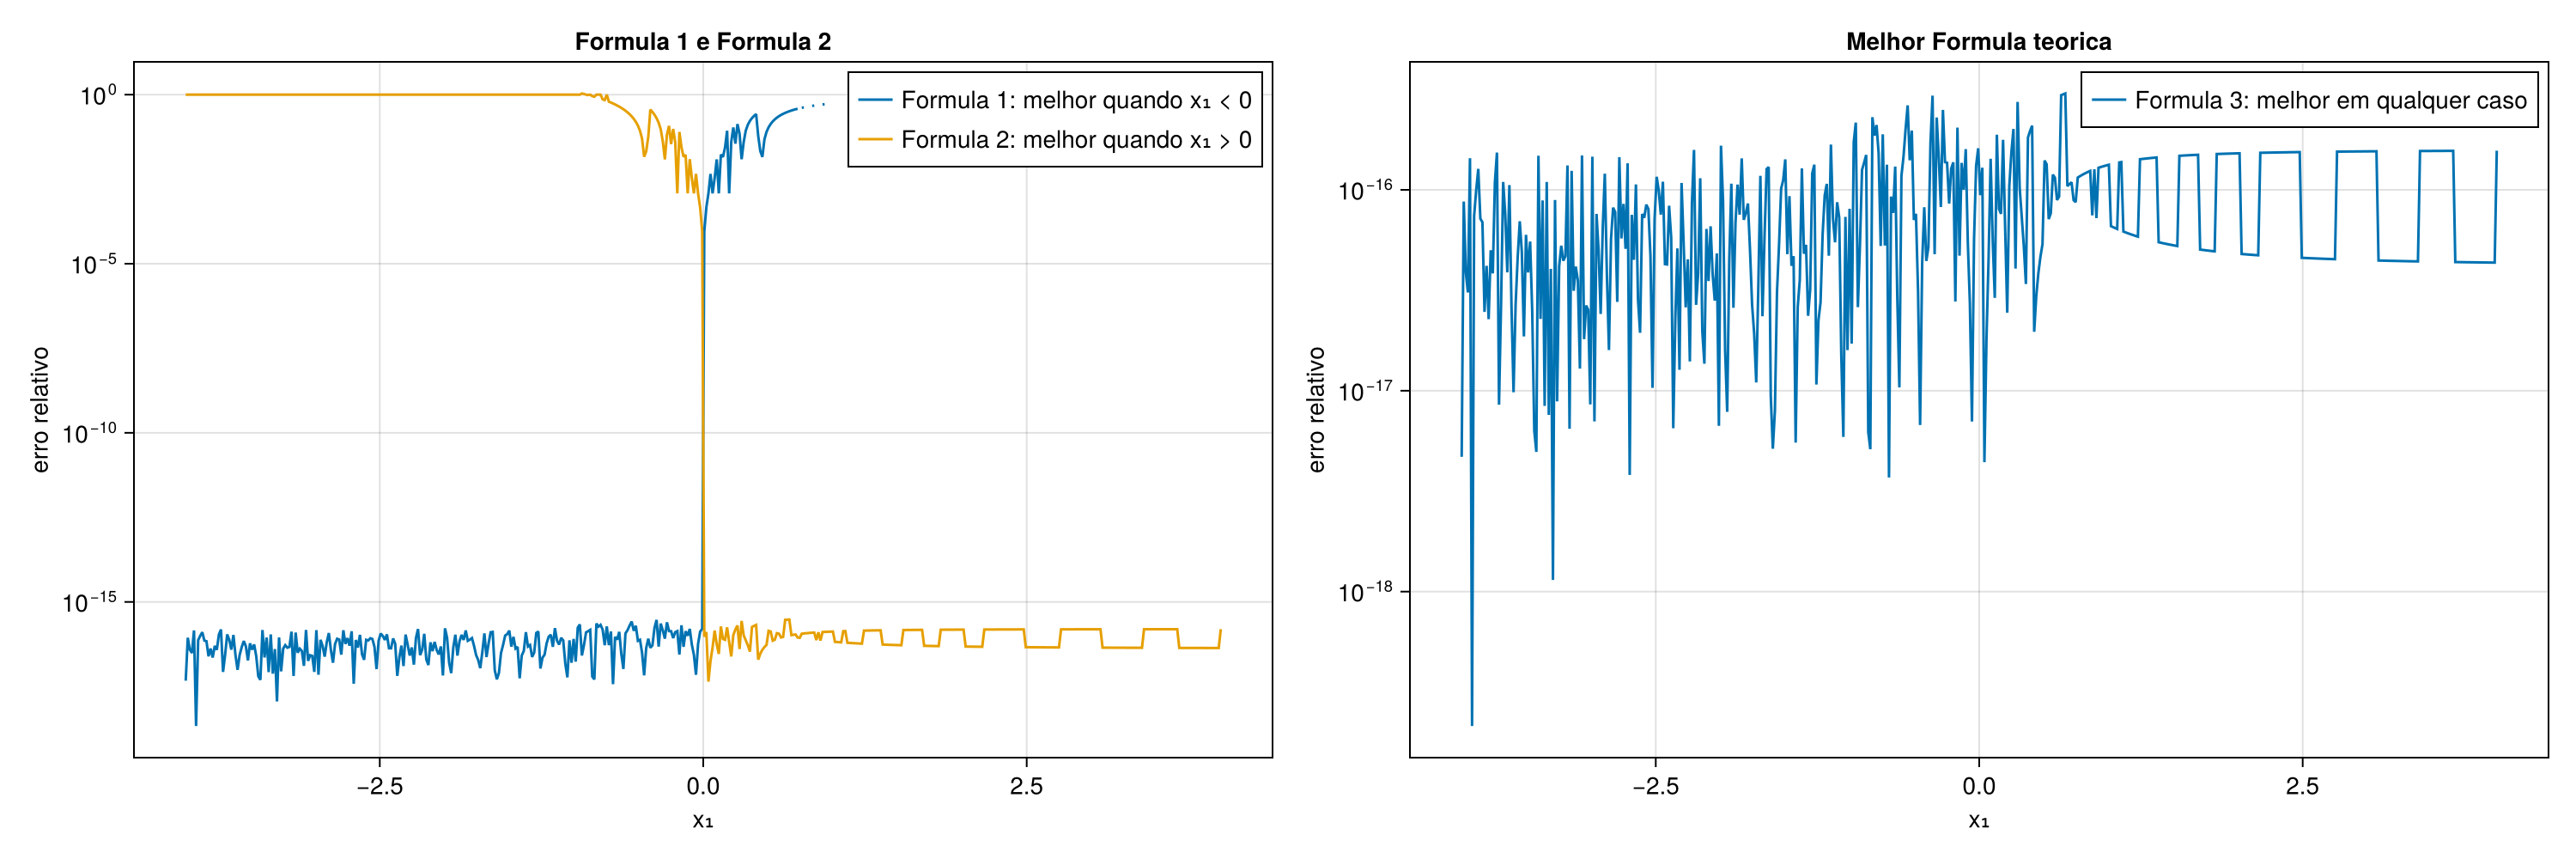

In [218]:
# tenta simular a presição perfeita usando muitas casas decimais
function β_ref(x)
    xb = BigFloat.(x)
    return calc_β(xb)
end

# calcula o erro relativo
function relerr(b_til, b)
    abs(b_til - b) / abs(b)
end

xs = range(-4, 4, length=500)

err1 = similar(xs, Float64)
err2 = similar(xs, Float64)
err3 = similar(xs, Float64)

for (i, x1) in pairs(xs)
    x = [x1, 1e-8]
    βtrue = β_ref(x)

    err1[i] = relerr(calc_β(x; type=:one),  βtrue)
    err2[i] = relerr(calc_β(x; type=:two),  βtrue)
    err3[i] = relerr(calc_β(x; type=:best), βtrue)
end

fig = Figure(size=(1500, 500))

ax1 = Axis(fig[1, 1],yscale=log10 ,title="Formula 1 e Formula 2", xlabel="x₁", ylabel="erro relativo")
ax2 = Axis(fig[1, 2],yscale=log10 ,title="Melhor Formula teorica", xlabel="x₁", ylabel="erro relativo")

lines!(ax1, xs, err1, label="Formula 1: melhor quando x₁ < 0")
lines!(ax1, xs, err2, label="Formula 2: melhor quando x₁ > 0")
lines!(ax2, xs, err3, label="Formula 3: melhor em qualquer caso")

axislegend(ax1, position = :rt)
axislegend(ax2, position = :rt)

fig



## item c)

In [4]:
struct Reflectores{T, V<:AbstractVector}
    β::T
    v::V
end

In [5]:
function reflector(x)
    norm_x = norm(x)

    v = float(x)
    β = calc_β(x)
    
    v[1] = -1 / (β * norm_x)

    return Reflectores(β, v)
end

reflector (generic function with 1 method)

# Questão 2

## item a)

In [6]:
function apply_reflector(Q::Reflectores, b::AbstractVector; j::Int = 1)
    @inbounds begin
        xsub = @view b[j:end]
        α = Q.β * dot(Q.v, xsub)
        @. xsub -= α * Q.v
    end
    return b 
end

apply_reflector (generic function with 1 method)

## item b)

Devemos testar para alguns valores de x para conprovar se a nossa função funciona de maneira adequada, quanto para valores x com mesma dimensão que v quanto para valores de x com dimensão maior.

1. Usaremos uma propriedade dos refletores de Householder $Q_x = I - 2\dfrac{xx^{*}}{x^{*}x}$ que diz:
$$
x = u - v \quad ||u|| = ||v|| \implies Q_x u = v
$$

Dessa forma criamos escolhemos $u$ e $v$ de maneira aleatoria, criamos o refletor, e usamos $\verb|apply_reflector|$ para confirmar se esta funcionando do jeito certo. Para testar vetores com dimensão maior, configuramos o mesmo teste, somente que agora tambem criamos um vetor $\verb|v_maior|$ que contem as primeiras k entradas aleatorias e as ultimas k entradas são as mesmas que o vetor $v$ então criamos o refletor da mesma forma que antes e aplicamos ele com a função $\verb|apply_reflector|$ em $\verb|v_maior|$ para depois verificar se as k primeiras entradas não foram alteradas e se as k ultimas entradas são iguais ao vetor $u$

Para medir se temos que tanto sucesso temos vamos ussar a acuracia como metrica.

In [7]:
P = 0
N = 0

# Caso de mesma dimensão
for k in 2:100
    u = rand(k)
    u = u / norm(u)

    v = rand(k)
    v = v / norm(v)

    x = u - v

    Q = Reflectores(2/x'x, x)

    isapprox(apply_reflector(Q, u), v) ? P += 1 : N+1
end

accuracy = P / P + N

1.0

Parece que funcona bem para vetores de mesma dimensão

In [17]:
P_sup = 0
N_sup = 0

P_sup = 0
P_inf = 0

# Caso dimensões diferentes
for k in 2:100
    u = rand(k)
    u = u / norm(u)

    v = rand(k)
    v = v / norm(v)

    sup = rand(k)
    v_maior = [sup; v]

    x = u - v

    Q = Reflectores(2/x'x, x)

    result = apply_reflector(Q, v_maior; j=k+1)

    isapprox(result[1:k], sup) ? P_sup += 1 : N_sup +=1
    isapprox(result[k+1:end], u) ? P_inf += 1 : N_inf +=1
end

accuracy_1 = P_sup / P_sup + N_sup
accuracy_2 = P_inf / P_inf + N_inf

display(accuracy_1)
display(accuracy_2)


1.0

1.0

continua funcionando bem para vetores de dimensão maior. Vamos a certificarnos que noss função tem complexidade O(n)

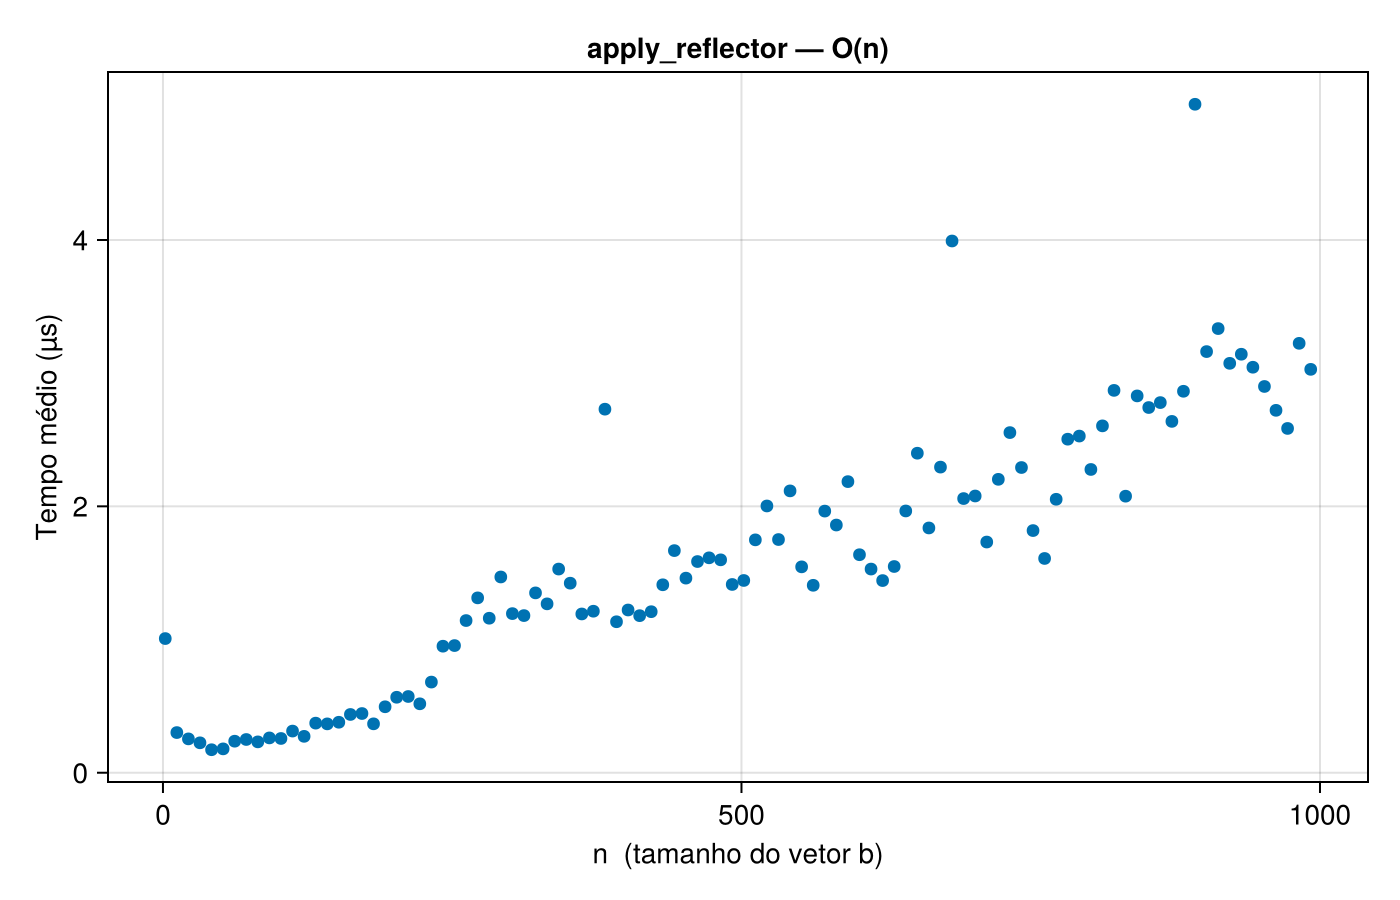

In [37]:
# Benchmark
sizes = 2:10:1000
times = Float64[]

for n in sizes
    v = normalize(randn(n))
    Q = Reflectores(2.0, v)
    b = randn(n)

    reps = 10

    for _ in 1:3; apply_reflector(Q, copy(b)); end  # warm-up

    t0 = time_ns()
    for _ in 1:reps; apply_reflector(Q, copy(b)); end
    push!(times, (time_ns() - t0) / reps / 1e3)  # µs
end

# Plot
fig = Figure(size = (700, 450))
ax  = Axis(fig[1, 1];
    xlabel = "n  (tamanho do vetor b)",
    ylabel = "Tempo médio (µs)",
    title  = "apply_reflector — O(n)")

scatter!(ax, collect(sizes), times; label = "medições")

fig

com esto podemos verificar que o crescimento é linear em funcao do numero de entradas do vetor b

## item c)

In [159]:
function apply_reflector(Q::Reflectores, A::AbstractMatrix, j::Int = 1)
    @inbounds begin
        Ablock = @view A[j:end,:]
        α = Q.β * (Q.v' * Ablock)
        Ablock .-= Q.v * α     
    end
end

apply_reflector (generic function with 5 methods)

## item d)

In [160]:
function rev_apply_reflector(Q::Reflectores, A::AbstractMatrix, j::Int = 1)
    @inbounds begin
        Ablock = @view A[:,j:end]
        α = Q.β
        Ablock .-= α * ((Ablock * Q.v) * Q.v')
    end
end

rev_apply_reflector (generic function with 2 methods)

## item e)

In [220]:
function to_hessenberg(A::AbstractMatrix; return_Q::Bool = false)
    n, _ = size(A)
    H = copy(A)
    reflectores = Vector{Reflectores}(undef, n - 2)

    for k in 1:(n-2)
        x = H[k+1:n, k]
        Qv = reflector(x)
        reflectores[k] = Qv
        apply_reflector(Qv, H, k+1)
        rev_apply_reflector(Qv, H, k+1)

        # Pela definição de v = x - ||x||e1, o valor resultante exato é ||x||
        H[k+1, k] = norm(x)
        if k+2 <= n
            H[k+2:n, k] .= 0 # Limpeza
        end
    end

    if return_Q
        Q = Matrix{Float64}(I, n, n)
        for k in 1:(n-2) 
            rev_apply_reflector(reflectores[k], Q, k+1)
        end

        return reflectores, H, Q
    end

    return reflectores, H
end

to_hessenberg (generic function with 1 method)

# Questão 3

## item a)

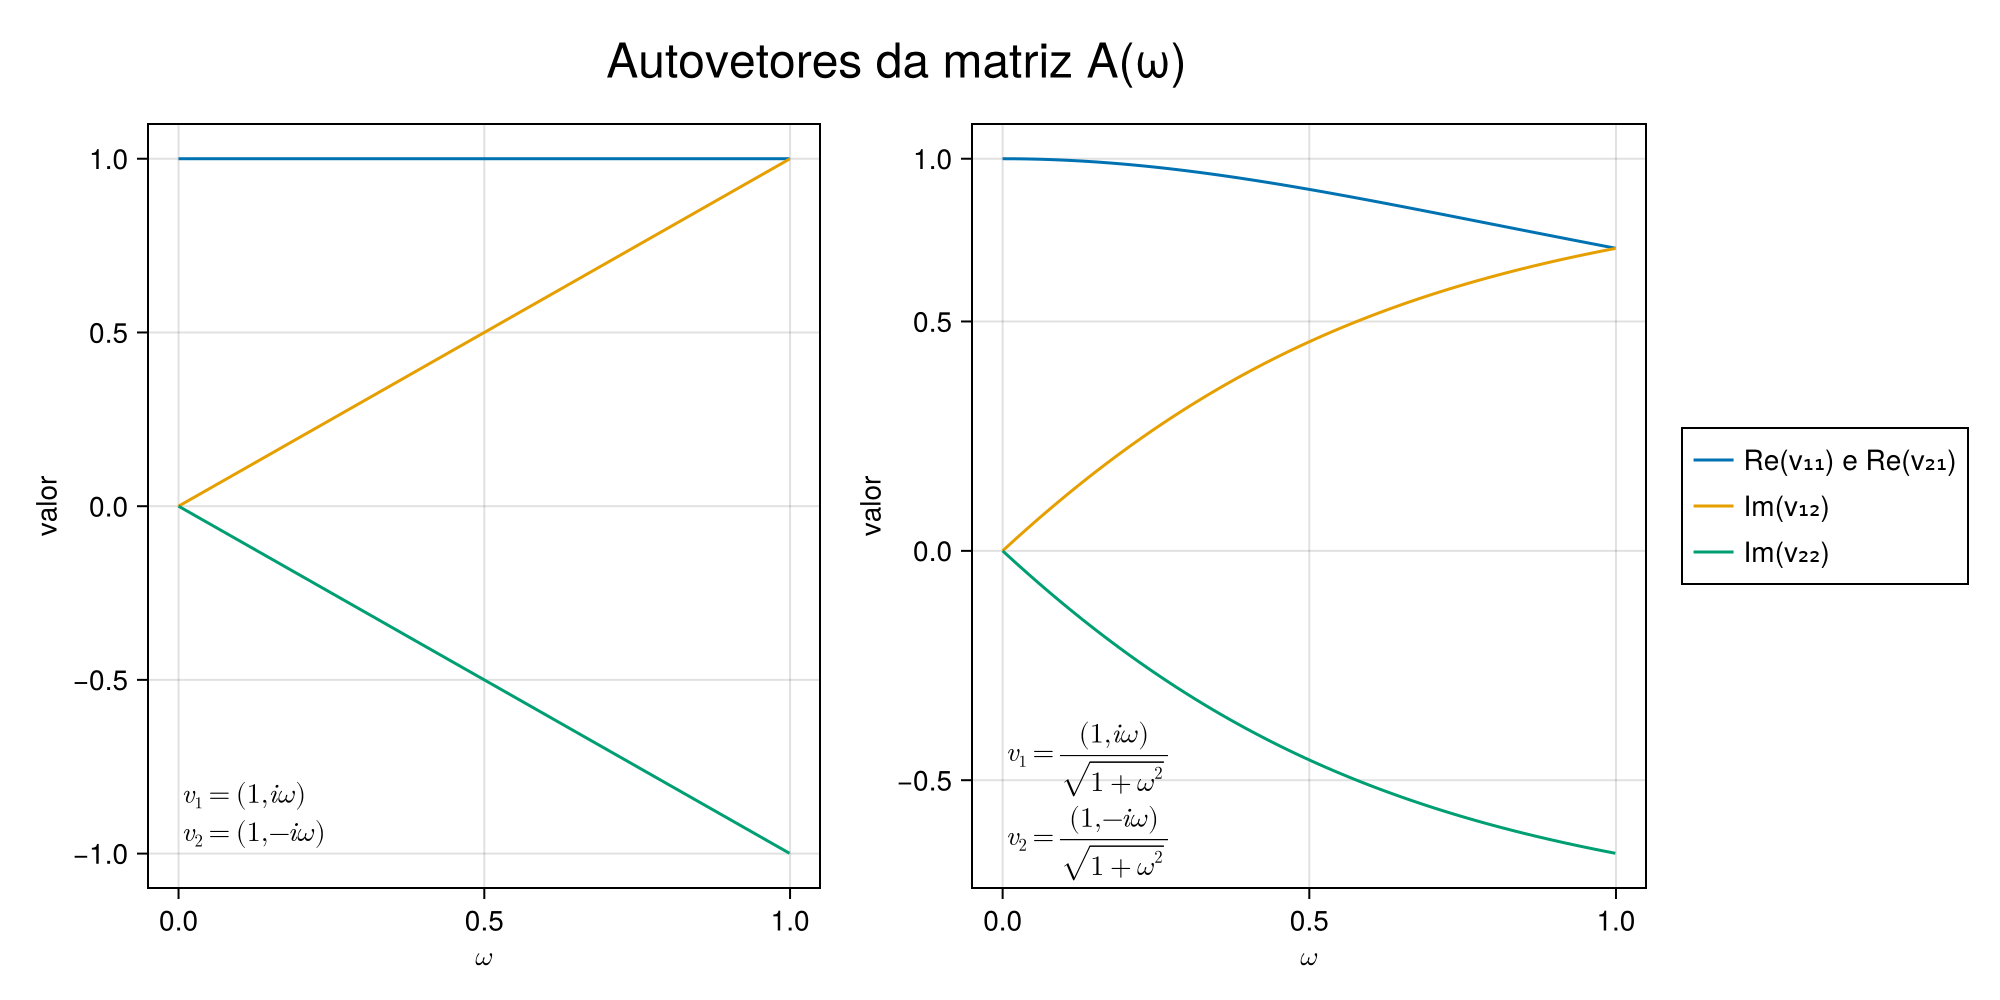

In [ ]:
ω = LinRange(0, 0.999, 100)

v11 = ones(length(ω))
v12 = im .* ω

v21 = v11
v22 = -v12

fig = Figure(
    size=(1000, 500)
)

ax1 = Axis(fig[1,1],
    xlabel = L"\omega",
    ylabel = "valor")

lines!(ax1, ω, real.(v11), label = "Re(v₁₁) e Re(v₂₁)")
lines!(ax1, ω, imag.(v12), label = "Im(v₁₂)")
lines!(ax1, ω, imag.(v22), label = "Im(v₂₂)")

text!(ax1, 0.05, 0.10, text = L"v_1 = (1,i\omega)", space = :relative)
text!(ax1, 0.05, 0.05, text = L"v_2 = (1,-i\omega)", space = :relative)

v11 = ones(length(ω)) ./ sqrt.(1 .+ ω .^ 2)
v12 = (im .* ω) ./ sqrt.(1 .+ ω .^ 2)

v21 = v11
v22 = -v12

ax2 = Axis(fig[1,2],
    xlabel = L"\omega",
    ylabel = "valor",
    )

lines!(ax2, ω, real.(v11), label = "Re(v₁₁) e Re(v₂₁)")
lines!(ax2, ω, imag.(v12), label = "Im(v₁₂)")
lines!(ax2, ω, imag.(v22), label = "Im(v₂₂)")

text!(ax2, 0.05, 0.12, text = L"v_1 = \frac{(1,i\omega)}{\sqrt{1+\omega^2}}", space = :relative)
text!(ax2, 0.05, 0.01, text = L"v_2 = \frac{(1,-i\omega)}{\sqrt{1+\omega^2}}", space = :relative)

Label(fig[0, :], "Autovetores da matriz A(ω)", fontsize = 24)
Legend(fig[1, 3], ax1)

fig

## item b)

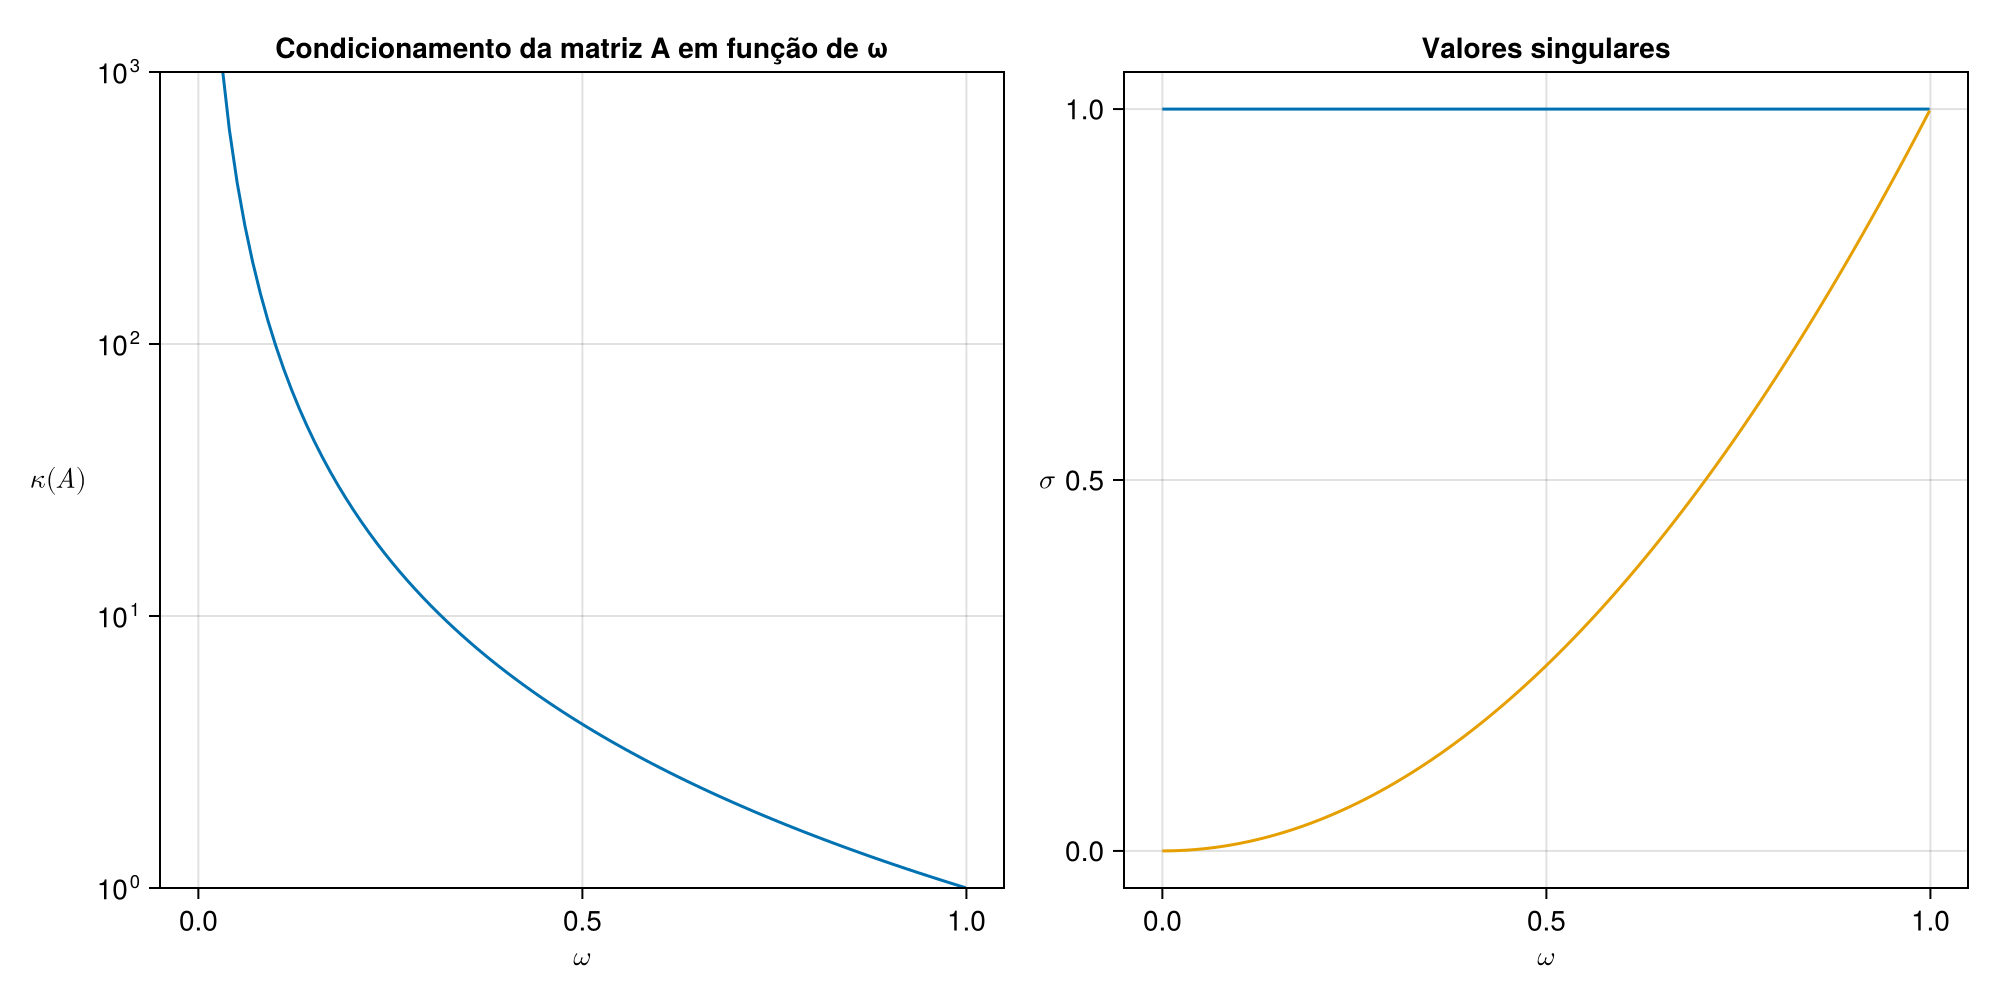

In [ ]:
function A(ω)
    return [zero(ω) one(ω); 
             -ω^2   zero(ω)]
end

ωs = LinRange(0, 0.999, 100)
σs = svdvals.(A.(ωs))
cond = getindex.(σs, 1) ./  getindex.(σs, 2) 

fig = Figure(
    size=(1000, 500)
)

ax0 = Axis(
    fig[1,1],
    title ="Condicionamento da matriz A em função de ω",
    xlabel= L"\omega",
    ylabel= L"\kappa(A)",
    ylabelrotation=0,
    yscale=log10
)

ax1 = Axis(
    fig[1,2],
    title="Valores singulares",
    xlabel=L"\omega",
    ylabel=L"\sigma",
    ylabelrotation=0
)

lines!(ax0, ωs, cond)
lines!(ax1, ωs, getindex.(σs, 1))
lines!(ax1, ωs, getindex.(σs, 2))

fig

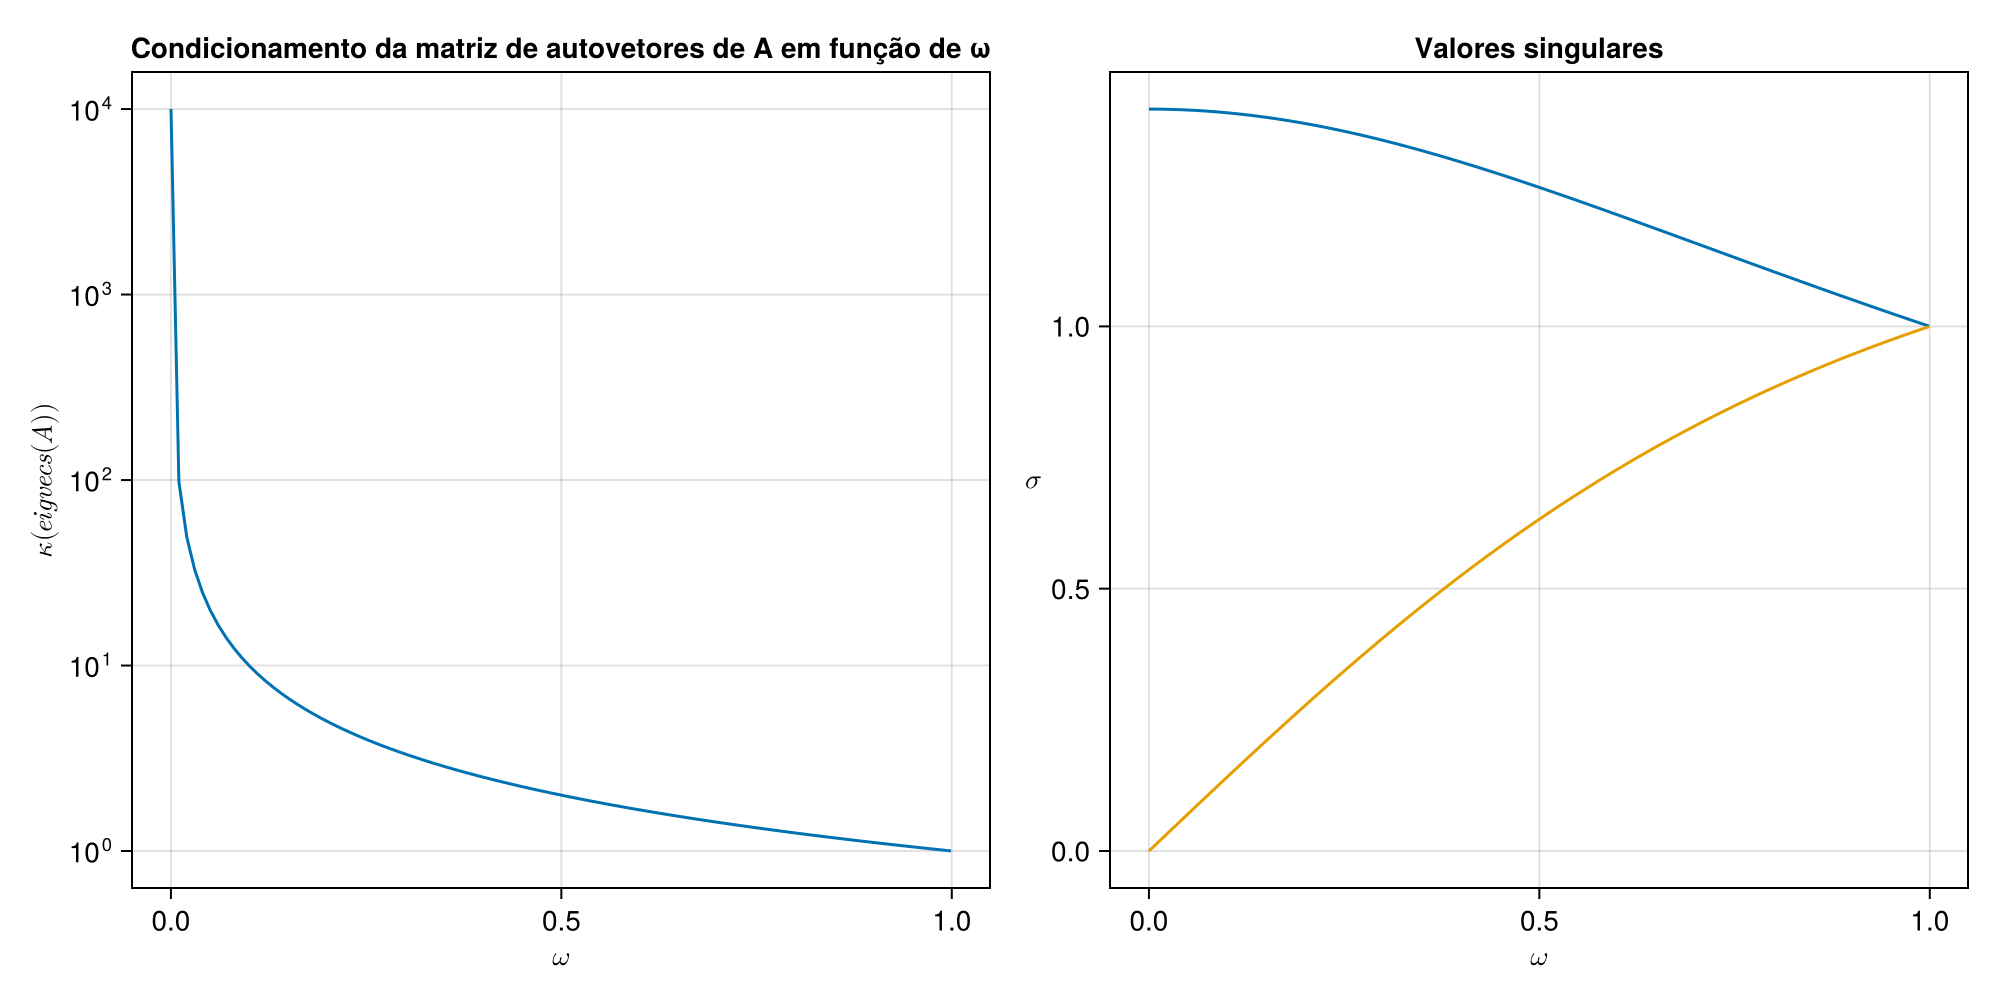

In [212]:
ωs = LinRange(0.0001, 0.999, 100)
σs = svdvals.(eigvecs.(A.(ωs)))
cond = getindex.(σs, 1) ./  getindex.(σs, 2) 

fig = Figure(
    size = (1000, 500)
)

ax0 = Axis(
    fig[1,1],
    title ="Condicionamento da matriz de autovetores de A em função de ω",
    xlabel= L"\omega",
    ylabel= L"\kappa(eigvecs(A))",
    yscale=log10
)

ax1 = Axis(
    fig[1,2],
    title="Valores singulares",
    xlabel=L"\omega",
    ylabel=L"\sigma",
    ylabelrotation=0
)

lines!(ax0, ωs, cond)
lines!(ax1, ωs, getindex.(σs, 1))
lines!(ax1, ωs, getindex.(σs, 2))

fig

## item C)

In [274]:
ts = [1e10, 1e5, 1e1]
ωs = LinRange(1e-16, 1, 1000)

function exp_num(t, ω)
    return [
    cos(ω*t)     sin(ω*t)/ω
   -ω*sin(ω*t)  cos(ω*t)
]
end

function exp_ref(t, ω)
    ωb = BigFloat(ω)
    tb = BigFloat(t)
    return exp_num(tb, ωb)
end

function relerr(A_til, A)
    return norm(A_til - A) / norm(A)
end

fig = Figure()

ax = Axis(
    fig[1,1],
    xlabel=L"\omega",
    title="Erro relativo da exponencial de tA(ω)",
    ylabel="Erro relativo",
    yscale=log10
)

for t in ts
    num = exp.(t * A.(ωs))
    ref = exp_ref.(t, ωs)

    err_rel = Float64.(relerr.(num, ref))

    lines!(ax, ωs, err_rel, label ="t = $t")
end

Legend(fig[1, 2], ax)

Legend()

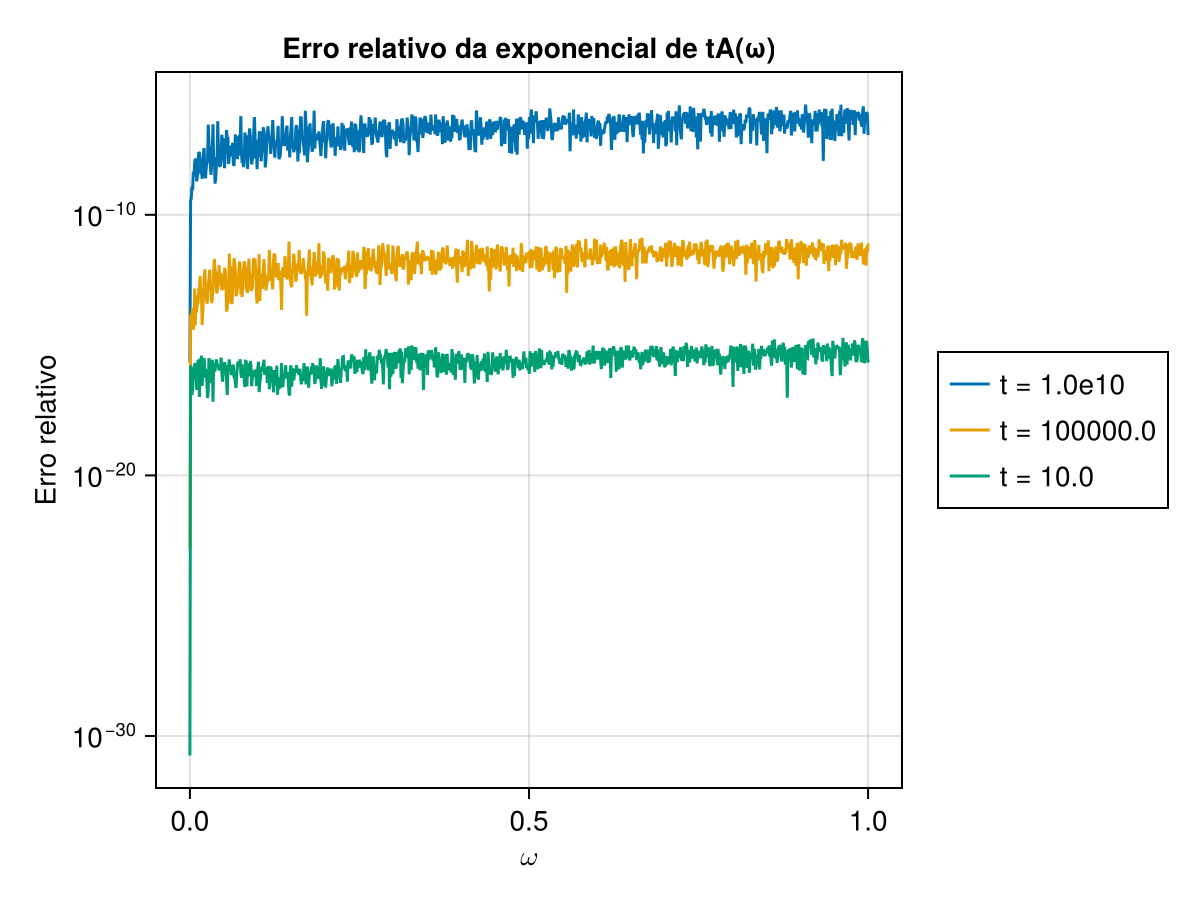

In [275]:
fig

In [273]:
t = [1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10]

exp_num.(t, 1e-18)

10-element Vector{Matrix{Float64}}:
 [1.0 10.0; -1.0000000000000001e-35 1.0]
 [1.0 100.0; -1.0000000000000001e-34 1.0]
 [1.0 1000.0; -1.0000000000000002e-33 1.0]
 [1.0 10000.0; -1.0e-32 1.0]
 [1.0 100000.0; -1.0e-31 1.0]
 [1.0 999999.9999999999; -1.0e-30 1.0]
 [1.0 1.0e7; -1.0000000000000002e-29 1.0]
 [1.0 1.0e8; -1.0000000000000001e-28 1.0]
 [1.0 1.0e9; -1.0000000000000002e-27 1.0]
 [1.0 1.0e10; -1.0e-26 1.0]